# CV552 Sign-Language Recognition — Training Pipelines

Trains every architecture once and saves the models, SVM features, and training histories to Google Drive. The companion notebook `02_evaluation_and_comparison.ipynb` loads those artifacts to produce the comparative analysis required by the project.

# Setup - Mount Google Drive

In [ ]:
import os, json
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

DRIVE_ROOT = '/content/drive/MyDrive/CV552_SignLanguage'
MODELS_DIR    = os.path.join(DRIVE_ROOT, 'models')
FEATURES_DIR  = os.path.join(DRIVE_ROOT, 'features')
HISTORY_DIR   = os.path.join(DRIVE_ROOT, 'history')

for d in (MODELS_DIR, FEATURES_DIR, HISTORY_DIR):
    os.makedirs(d, exist_ok=True)

def save_history(name, history_obj):
    path = os.path.join(HISTORY_DIR, f'{name}.json')
    with open(path, 'w') as f:
        json.dump({k: [float(v) for v in vals] for k, vals in history_obj.items()}, f)
    print(f'  saved history -> {path}')

print('Drive ready. Artifacts will be written under:', DRIVE_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive ready. Artifacts will be written under: /content/drive/MyDrive/CV552_SignLanguage


# Data loading & Preprocessing

Dataset URL: https://www.kaggle.com/datasets/datamunge/sign-language-mnist
License(s): CC0-1.0
100% 62.6M/62.6M [00:00<00:00, 111MB/s]

Download and extraction complete!

Data loaded successfully!
Training set shape: (27455, 785)
Testing set shape: (7172, 785)



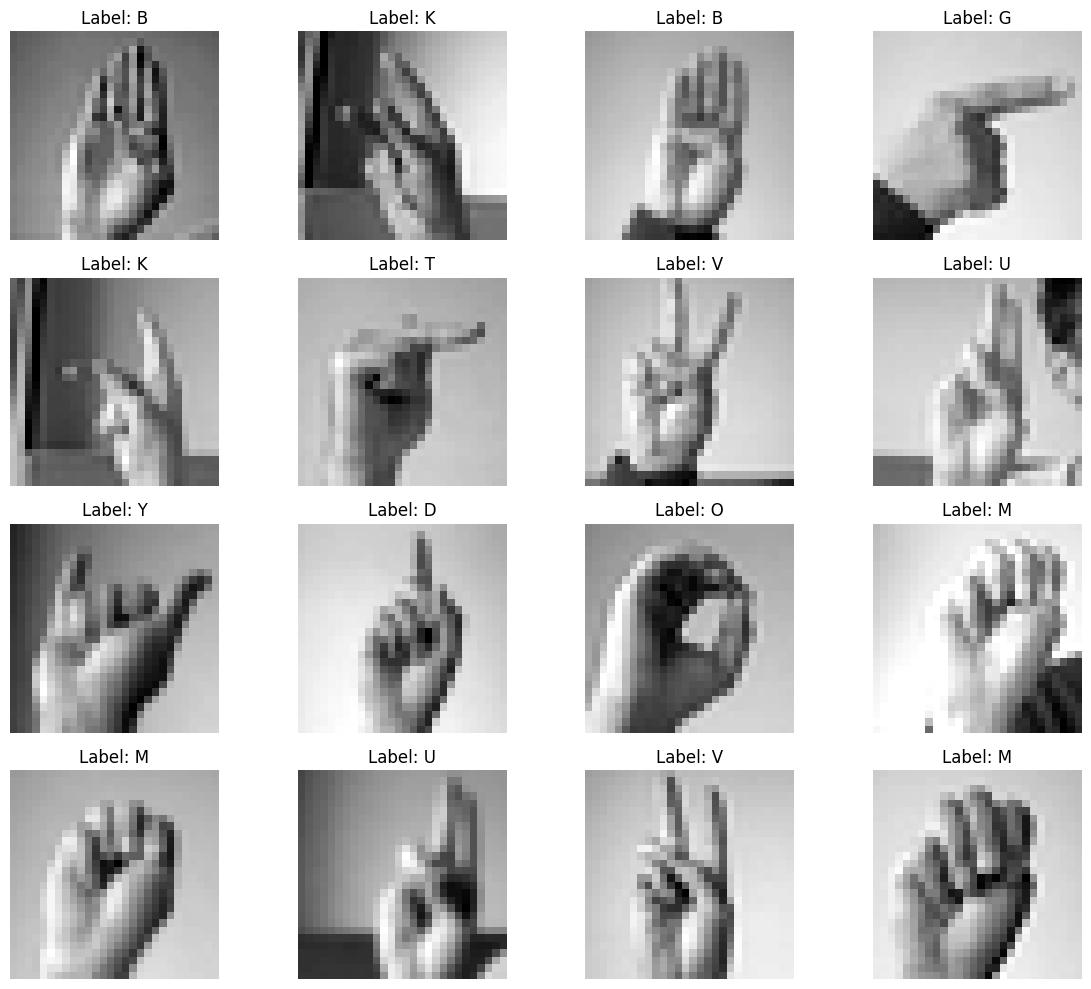

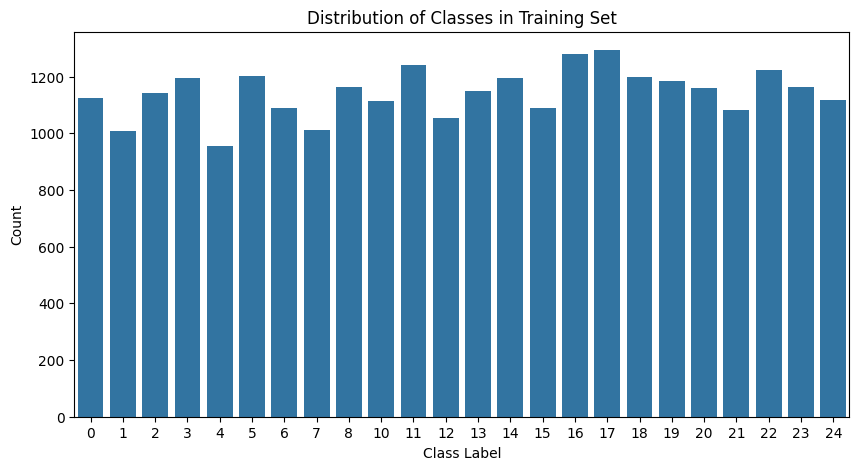

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.environ['KAGGLE_USERNAME'] = "abdullahashiry" 
os.environ['KAGGLE_KEY'] = "KGAT_331632d901a6cb7a05431b55135bd8c2"

print("Downloading dataset...")
!kaggle datasets download -d datamunge/sign-language-mnist --unzip
print("Download and extraction complete!\n")

train_path = 'sign_mnist_train/sign_mnist_train.csv'
test_path = 'sign_mnist_test/sign_mnist_test.csv'

if not os.path.exists(train_path):
    train_path = 'sign_mnist_train.csv'
    test_path = 'sign_mnist_test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Data loaded successfully!")
print(f"Training set shape: {train_df.shape}")
print(f"Testing set shape: {test_df.shape}\n")

y_train = train_df['label'].values
x_train = train_df.drop('label', axis=1).values

y_test = test_df['label'].values
x_test = test_df.drop('label', axis=1).values

x_train = x_train.reshape(-1, 28, 28)
x_test = x_test.reshape(-1, 28, 28)

alphabet_mapping = {0:'A', 1:'B', 2:'C', 3:'D', 4:'E', 5:'F', 6:'G', 7:'H', 8:'I',
                    10:'K', 11:'L', 12:'M', 13:'N', 14:'O', 15:'P', 16:'Q', 17:'R',
                    18:'S', 19:'T', 20:'U', 21:'V', 22:'W', 23:'X', 24:'Y'}

plt.figure(figsize=(12, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    idx = np.random.randint(0, len(x_train))
    plt.imshow(x_train[idx], cmap='gray')
    letter = alphabet_mapping[y_train[idx]]
    plt.title(f"Label: {letter}")
    plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(x=y_train)
plt.title("Distribution of Classes in Training Set")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.show()

# Classical Pipeline

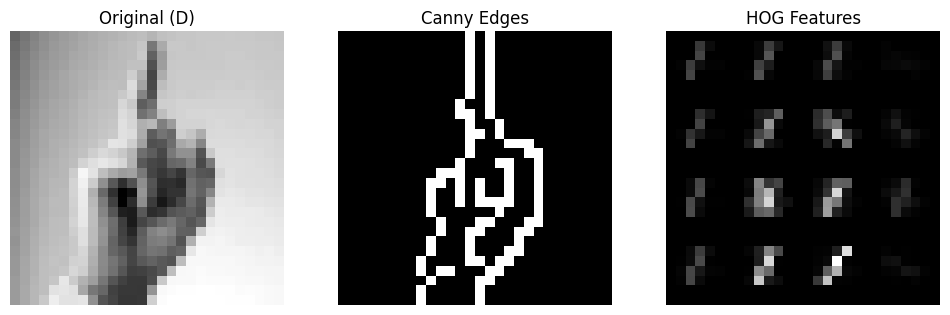

Extracting HOG features from training data...
  325 features per image in 106.95s
Extracting HOG features from test data...
  saved features -> /content/drive/MyDrive/CV552_SignLanguage/features/svm_hog_features.npz

Training SVM (RBF kernel)...
  done in 101.91s
  saved model -> /content/drive/MyDrive/CV552_SignLanguage/models/svm_hog.joblib

Test Accuracy: 97.09%

              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      0.97      0.99       432
           C       1.00      0.93      0.96       310
           D       1.00      1.00      1.00       245
           E       0.96      1.00      0.98       498
           F       1.00      1.00      1.00       247
           G       1.00      0.94      0.97       348
           H       1.00      1.00      1.00       436
           I       1.00      1.00      1.00       288
           K       1.00      1.00      1.00       331
           L       1.00      1.00   

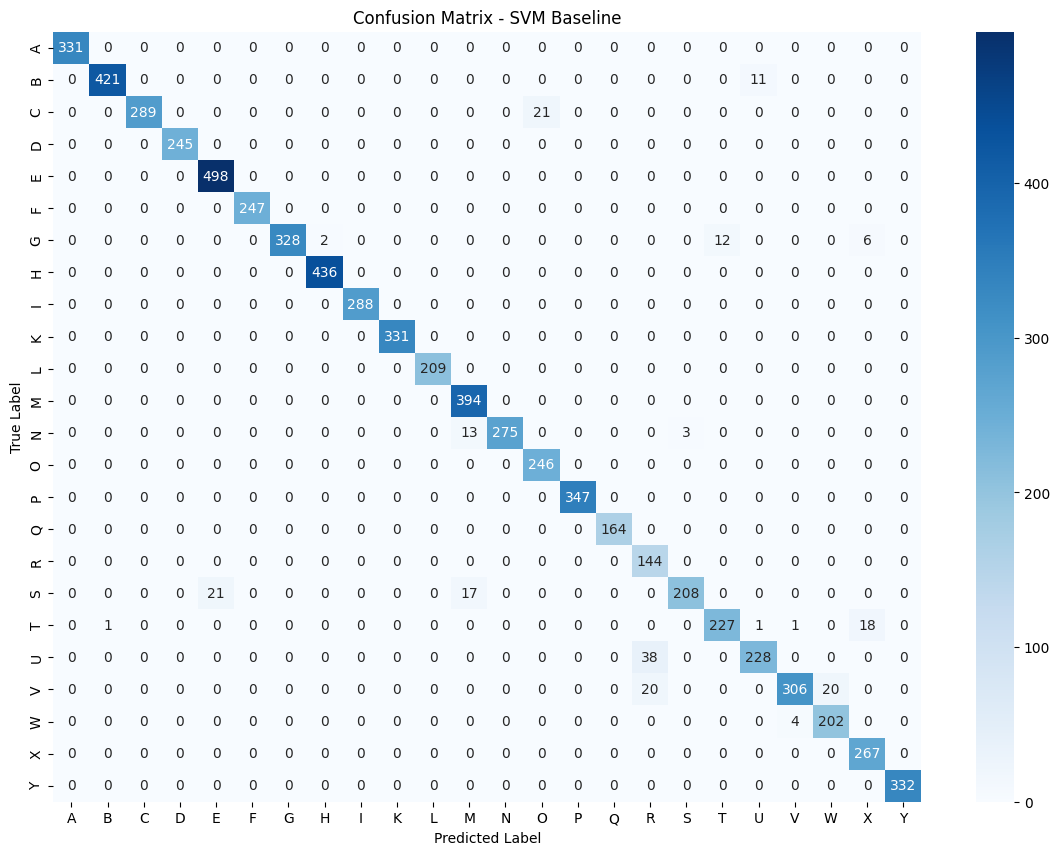

In [ ]:
import cv2
import numpy as np
import joblib, os
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

def extract_features(image_2d, visualize=False):
    img_uint8 = image_2d.astype(np.uint8)
    blurred = cv2.GaussianBlur(img_uint8, (3, 3), 0)
    edges = cv2.Canny(blurred, threshold1=50, threshold2=150)

    features, hog_img = hog(blurred, orientations=9,
                            pixels_per_cell=(7, 7),
                            cells_per_block=(2, 2),
                            visualize=True,
                            block_norm='L2-Hys')

    edge_density = np.sum(edges) / (255.0 * 28 * 28)
    final_feature_vector = np.append(features, edge_density)

    if visualize:
        return final_feature_vector, edges, hog_img
    return final_feature_vector

sample_idx = 0
sample_img = x_train[sample_idx]
sample_label = alphabet_mapping[y_train[sample_idx]]
_, edges_img, hog_img = extract_features(sample_img, visualize=True)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
ax1.imshow(sample_img, cmap='gray'); ax1.set_title(f'Original ({sample_label})'); ax1.axis('off')
ax2.imshow(edges_img, cmap='gray');  ax2.set_title('Canny Edges');   ax2.axis('off')
ax3.imshow(hog_img,    cmap='gray'); ax3.set_title('HOG Features');  ax3.axis('off')
plt.show()

print("Extracting HOG features from training data...")
t0 = time.time()
x_train_features = np.array([extract_features(img) for img in x_train])
print(f"  {x_train_features.shape[1]} features per image in {time.time() - t0:.2f}s")

print("Extracting HOG features from test data...")
x_test_features = np.array([extract_features(img) for img in x_test])

np.savez_compressed(os.path.join(FEATURES_DIR, 'svm_hog_features.npz'),
                    x_train=x_train_features, y_train=y_train,
                    x_test=x_test_features,   y_test=y_test)
print("  saved features ->", os.path.join(FEATURES_DIR, 'svm_hog_features.npz'))

print("\nTraining SVM (RBF kernel)...")
t0 = time.time()
svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42, probability=True)
svm_model.fit(x_train_features, y_train)
print(f"  done in {time.time() - t0:.2f}s")

joblib.dump(svm_model, os.path.join(MODELS_DIR, 'svm_hog.joblib'))
print("  saved model ->", os.path.join(MODELS_DIR, 'svm_hog.joblib'))

y_pred = svm_model.predict(x_test_features)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%\n")

target_names = [alphabet_mapping[i] for i in sorted(list(set(y_test)))]
print(classification_report(y_test, y_pred, target_names=target_names))

plt.figure(figsize=(14, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - SVM Baseline')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.show()

# Custom CNN

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 899,737 (3.43 MB)

 Trainable params: 899,289 (3.43 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.3605 - loss: 2.0255 - val_accuracy: 0.0949 - val_loss: 3.6097
Epoch 2/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6280 - loss: 1.0074 - val_accuracy: 0.9494 - val_loss: 0.2628
Epoch 3/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7276 - loss: 0.7302 - val_accuracy: 0.9794 - val_loss: 0.1212
Epoch 4/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7903 - loss: 0.5569 - val_accuracy: 0.9869 - val_loss: 0.0771
Epoch 5/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8227 - loss: 0.4644 - val_accuracy: 0.9754 - val_loss: 0.0889
Epoch 6/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8447 - loss: 0.3982 - val_accuracy: 0.9889 - val_loss: 0.0576
Epoch 7/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8612 - loss: 0.3669 - val_accuracy: 0.9980 - val_loss: 0.0167
Epoch 8/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8689 - loss: 0.3480 - val_accuracy: 

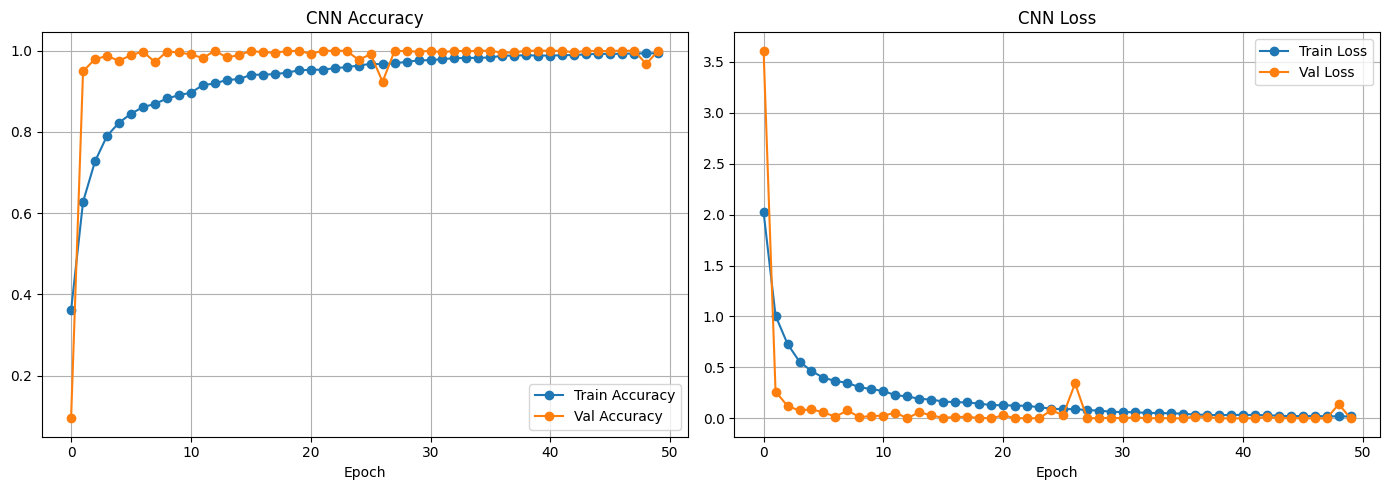

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

x_train_cnn = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test_cnn  = x_test.reshape(-1, 28, 28, 1).astype('float32')  / 255.0
num_classes = 25

model = models.Sequential([
    layers.Conv2D(32, (3, 3), input_shape=(28, 28, 1), padding='same'),
    layers.BatchNormalization(), layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)), layers.Dropout(0.1),

    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(), layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)), layers.Dropout(0.2),

    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(), layers.Activation('relu'),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

history = model.fit(x_train_cnn, y_train,
                    epochs=50, batch_size=64,
                    validation_split=0.2)

test_loss, test_acc = model.evaluate(x_test_cnn, y_test, verbose=2)
print(f"\nFinal Custom CNN Test Accuracy: {test_acc * 100:.2f}%")

model.save(os.path.join(MODELS_DIR, 'custom_cnn.keras'))
save_history('custom_cnn', history.history)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy',   marker='o')
plt.title('CNN Accuracy'); plt.xlabel('Epoch'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss',   marker='o')
plt.title('CNN Loss'); plt.xlabel('Epoch'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

# Data Augmentation & LR Scheduling

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
import os

x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train_cnn, y_train, test_size=0.2, random_state=42
)

datagen = ImageDataGenerator(
    rotation_range=10, zoom_range=0.1,
    width_shift_range=0.1, height_shift_range=0.1
)
datagen.fit(x_train_split)

aug_ckpt_path = os.path.join(MODELS_DIR, 'cnn_augmented.keras')
checkpoint_callback = ModelCheckpoint(
    filepath=aug_ckpt_path,
    monitor='val_accuracy', save_best_only=True, mode='max', verbose=1
)
lr_reduction = ReduceLROnPlateau(
    monitor='val_accuracy', patience=3, factor=0.5, min_lr=1e-5, verbose=1
)

history_aug = model.fit(
    datagen.flow(x_train_split, y_train_split, batch_size=64),
    epochs=50,
    validation_data=(x_val_split, y_val_split),
    callbacks=[checkpoint_callback, lr_reduction]
)

model.load_weights(aug_ckpt_path)
test_loss, test_acc = model.evaluate(x_test_cnn, y_test, verbose=2)
print(f"\nFinal Augmented CNN Test Accuracy: {test_acc * 100:.2f}%")

save_history('cnn_augmented', history_aug.history)

Epoch 1/50
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8182 - loss: 0.7114
Epoch 1: val_accuracy improved from None to 0.99982, saving model to /content/drive/MyDrive/CV552_SignLanguage/models/cnn_augmented.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CV552_SignLanguage/models/cnn_augmented.keras
344/344 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8554 - loss: 0.5038 - val_accuracy: 0.9998 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 2/50
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9115 - loss: 0.2776
Epoch 2: val_accuracy improved from 0.99982 to 1.00000, saving model to /content/drive/MyDrive/CV552_SignLanguage/models/cnn_augmented.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CV552_SignLanguage/models/cnn_augmented.keras
344/344 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9186 - loss: 0.2580 - val_accuracy: 1.0000 - val_loss: 3.3506e-04 - learning_rate: 0.0010
Epoch 3/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/s

# Transfer Learning - MobileNetV2 (Head Only)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import os

x_train_tl = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test_tl  = x_test.reshape(-1, 28, 28, 1).astype('float32')  / 255.0

x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train_tl, y_train, test_size=0.2, random_state=42
)

base_model = MobileNetV2(weights='imagenet', include_top=False,
                         input_shape=(96, 96, 3))
base_model.trainable = False

model_tl = models.Sequential([
    layers.InputLayer(input_shape=(28, 28, 1)),
    layers.Lambda(lambda x: tf.image.grayscale_to_rgb(x)),
    layers.Resizing(96, 96),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(25, activation='softmax')
])
model_tl.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
model_tl.summary()

mnet_ckpt_path = os.path.join(MODELS_DIR, 'mobilenetv2_head.keras')
checkpoint_tl = ModelCheckpoint(mnet_ckpt_path,
                                monitor='val_accuracy', save_best_only=True, verbose=1)
lr_reduction_tl = ReduceLROnPlateau(monitor='val_accuracy',
                                    patience=2, factor=0.5, min_lr=1e-5, verbose=1)

history_tl = model_tl.fit(x_train_split, y_train_split,
                          epochs=15, batch_size=64,
                          validation_data=(x_val_split, y_val_split),
                          callbacks=[checkpoint_tl, lr_reduction_tl])

model_tl.load_weights(mnet_ckpt_path)
test_loss_tl, test_acc_tl = model_tl.evaluate(x_test_tl, y_test, verbose=2)
print(f"\nFinal MobileNetV2 (head only) Test Accuracy: {test_acc_tl * 100:.2f}%")

save_history('mobilenetv2_head', history_tl.history)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_3 (Lambda)               │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_3 (Resizing)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,425,177 (9.25 MB)

 Trainable params: 167,193 (653.10 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5427 - loss: 1.5538
Epoch 1: val_accuracy improved from None to 0.97851, saving model to /content/drive/MyDrive/CV552_SignLanguage/models/mobilenetv2_head.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CV552_SignLanguage/models/mobilenetv2_head.keras
344/344 ━━━━━━━━━━━━━━━━━━━━ 28s 54ms/step - accuracy: 0.7355 - loss: 0.8743 - val_accuracy: 0.9785 - val_loss: 0.1343 - learning_rate: 0.0010
Epoch 2/15
341/344 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9244 - loss: 0.2562
Epoch 2: val_accuracy improved from 0.97851 to 0.99253, saving model to /content/drive/MyDrive/CV552_SignLanguage/models/mobilenetv2_head.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CV552_SignLanguage/models/mobilenetv2_head.keras
344/344 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9384 - loss: 0.2119 - val_accuracy: 0.9925 - val_loss: 0.0490 - learning_rate: 0.0010
Epoch 3/15
340/344 ━━━━━━━━━━━━━━━━━━━━ 0s

# Transfer Learning - EfficientNetB0 (Head Only)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import os

x_train_eff = x_train.reshape(-1, 28, 28, 1).astype('float32')
x_test_eff  = x_test.reshape(-1, 28, 28, 1).astype('float32')

x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train_eff, y_train, test_size=0.2, random_state=42
)

IMG_SIZE = 224 

effnet_base = EfficientNetB0(weights='imagenet', include_top=False,
                             input_shape=(IMG_SIZE, IMG_SIZE, 3))
effnet_base.trainable = False

model_eff = models.Sequential([
    layers.InputLayer(input_shape=(28, 28, 1)),
    layers.Lambda(lambda x: tf.image.grayscale_to_rgb(x)),
    layers.Resizing(IMG_SIZE, IMG_SIZE),
    layers.Lambda(effnet_preprocess),
    effnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(25, activation='softmax'),
], name='efficientnetb0_head')

model_eff.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
model_eff.summary()

eff_head_ckpt = os.path.join(MODELS_DIR, 'efficientnetb0_head.keras')
ckpt_eff = ModelCheckpoint(eff_head_ckpt, monitor='val_accuracy',
                           save_best_only=True, verbose=1)
lr_eff = ReduceLROnPlateau(monitor='val_accuracy', patience=2,
                           factor=0.5, min_lr=1e-5, verbose=1)

history_eff = model_eff.fit(x_train_split, y_train_split,
                            epochs=15, batch_size=64,
                            validation_data=(x_val_split, y_val_split),
                            callbacks=[ckpt_eff, lr_eff])

model_eff.load_weights(eff_head_ckpt)
_, eff_head_acc = model_eff.evaluate(x_test_eff, y_test, verbose=2)
print(f"\nFinal EfficientNetB0 (head only) Test Accuracy: {eff_head_acc * 100:.2f}%")

save_history('efficientnetb0_head', history_eff.history)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "efficientnetb0_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_4 (Lambda)               │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_4 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_5 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,216,764 (16.09 MB)

 Trainable params: 167,193 (653.10 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.5470 - loss: 1.5648
Epoch 1: val_accuracy improved from None to 0.98962, saving model to /content/drive/MyDrive/CV552_SignLanguage/models/efficientnetb0_head.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CV552_SignLanguage/models/efficientnetb0_head.keras
344/344 ━━━━━━━━━━━━━━━━━━━━ 114s 245ms/step - accuracy: 0.7392 - loss: 0.8856 - val_accuracy: 0.9896 - val_loss: 0.0894 - learning_rate: 0.0010
Epoch 2/15
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9236 - loss: 0.2638
Epoch 2: val_accuracy improved from 0.98962 to 0.99690, saving model to /content/drive/MyDrive/CV552_SignLanguage/models/efficientnetb0_head.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CV552_SignLanguage/models/efficientnetb0_head.keras
344/344 ━━━━━━━━━━━━━━━━━━━━ 27s 79ms/step - accuracy: 0.9353 - loss: 0.2263 - val_accuracy: 0.9969 - val_loss: 0.0274 - learning_rate: 0.0010
Epoch 3/15
343/344 ━━━━━━━

# Transfer Learning - EfficientNetB0 (Fine-tuned)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import os

effnet_base.trainable = True
for layer in effnet_base.layers[:-40]:
    layer.trainable = False

for layer in effnet_base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model_eff.compile(optimizer=Adam(learning_rate=1e-5),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

eff_ft_ckpt = os.path.join(MODELS_DIR, 'efficientnetb0_finetuned.keras')
ckpt_ft = ModelCheckpoint(eff_ft_ckpt, monitor='val_accuracy',
                          save_best_only=True, verbose=1)
lr_ft   = ReduceLROnPlateau(monitor='val_accuracy', patience=2,
                            factor=0.5, min_lr=1e-7, verbose=1)
es_ft   = EarlyStopping(monitor='val_accuracy', patience=4,
                        restore_best_weights=True, verbose=1)

history_eff_ft = model_eff.fit(x_train_split, y_train_split,
                               epochs=20, batch_size=32,
                               validation_data=(x_val_split, y_val_split),
                               callbacks=[ckpt_ft, lr_ft, es_ft])

model_eff.load_weights(eff_ft_ckpt)
_, eff_ft_acc = model_eff.evaluate(x_test_eff, y_test, verbose=2)
print(f"\nFinal EfficientNetB0 (fine-tuned) Test Accuracy: {eff_ft_acc * 100:.2f}%")

save_history('efficientnetb0_finetuned', history_eff_ft.history)

Epoch 1/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9867 - loss: 0.0488
Epoch 1: val_accuracy improved from None to 1.00000, saving model to /content/drive/MyDrive/CV552_SignLanguage/models/efficientnetb0_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CV552_SignLanguage/models/efficientnetb0_finetuned.keras
687/687 ━━━━━━━━━━━━━━━━━━━━ 99s 101ms/step - accuracy: 0.9885 - loss: 0.0418 - val_accuracy: 1.0000 - val_loss: 6.5150e-04 - learning_rate: 1.0000e-05
Epoch 2/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9906 - loss: 0.0344
Epoch 2: val_accuracy did not improve from 1.00000
687/687 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - accuracy: 0.9917 - loss: 0.0319 - val_accuracy: 1.0000 - val_loss: 3.8254e-04 - learning_rate: 1.0000e-05
Epoch 3/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9920 - loss: 0.0266
Epoch 3: val_accuracy did not improve from 1.00000

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.99999987368937